# PCA model

In [ ]:
!pip install pyspark matplotlib seaborn pandas

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("Swasthya-Matrix-Training") \
    .getOrCreate()

print("Spark Session created successfully!")

Spark Session created successfully!


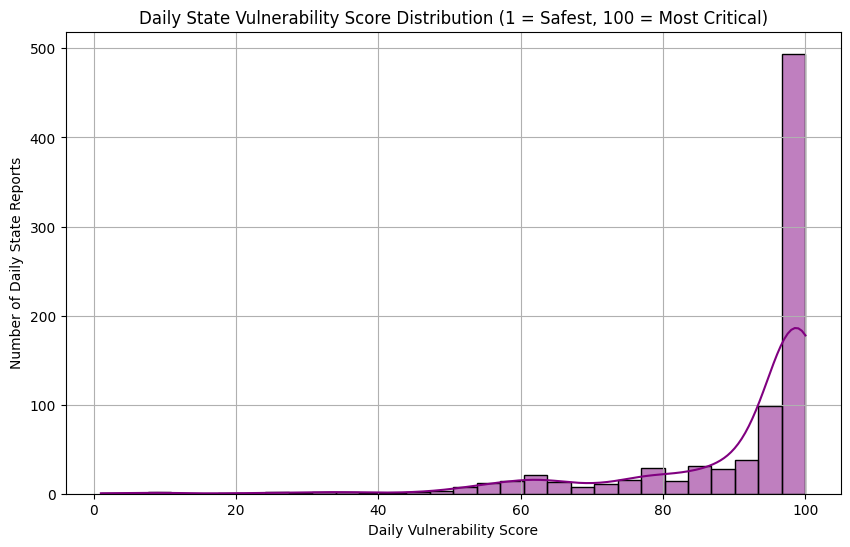

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA, MinMaxScaler
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

negative_features = [
    'Child_Diarrhoea', 'Child_TB', 'Infant_Death_Sepsis',
    'Maternal_Death_Bleeding', 'Adult_Death_TB', 'Adult_Suicide',
    'Child_Malaria', 'Severe_Anaemia_Treated'
]

pca_assembler = VectorAssembler(inputCols=negative_features, outputCol="negative_features_vec")
df_pca_assembled = pca_assembler.transform(df)

pca_scaler = StandardScaler(inputCol="negative_features_vec", outputCol="scaled_negative_features", withStd=True, withMean=True)
pca_scaler_model = pca_scaler.fit(df_pca_assembled)
df_pca_scaled = pca_scaler_model.transform(df_pca_assembled)

pca_index = PCA(k=1, inputCol="scaled_negative_features", outputCol="raw_pca_score")
pca_index_model = pca_index.fit(df_pca_scaled)
df_pca_result = pca_index_model.transform(df_pca_scaled)

df_pca_result = df_pca_result.withColumn("raw_score_scalar", vector_to_array("raw_pca_score")[0])

score_assembler = VectorAssembler(inputCols=["raw_score_scalar"], outputCol="raw_score_vec")
df_score_assembled = score_assembler.transform(df_pca_result)

min_max_scaler = MinMaxScaler(inputCol="raw_score_vec", outputCol="final_vulnerability_vec", min=1.0, max=100.0)
min_max_model = min_max_scaler.fit(df_score_assembled)
df_final_score = min_max_model.transform(df_score_assembled)

df_final_score = df_final_score.withColumn("Vulnerability_Score", vector_to_array("final_vulnerability_vec")[0])

scores = df_final_score.select("Vulnerability_Score").rdd.flatMap(lambda x: x).collect()

plt.figure(figsize=(10, 6))
sns.histplot(scores, bins=30, kde=True, color='purple')
plt.title("Daily State Vulnerability Score Distribution (1 = Safest, 100 = Most Critical)")
plt.xlabel("Daily Vulnerability Score")
plt.ylabel("Number of Daily State Reports")
plt.grid(True)
plt.show()

pca_index_model.write().overwrite().save("swasthya_pca_vulnerability.model")
min_max_model.write().overwrite().save("swasthya_score_scaler.model")